In [1]:
import sys, random
import os
import numpy as np
import json
import torch
import torch.nn as nn
import torchvision.transforms as T
from torch.utils.data import DataLoader
from omegaconf import OmegaConf

warnings = __import__('warnings')
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../../..'))

In [2]:
from DL.models.custom_classifier_from_config import CustomClassifierFromConfig
from DL.trainers.model_trainer import ModelTrainer
from DL.data.combined_dataset import CombinedDataset
from DL.loggers.experiment_logger import ExperimentLogger
from DL.visualization.visualizer import ExperimentVisualizer

In [3]:
def seed_everything(seed: int = 42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42) # Фиксируем сид

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [5]:
experiment_name = "arcface_GAN_PixelCount"
logger = ExperimentLogger(experiment_name, base_dir=".")
visualizer = ExperimentVisualizer(logger)

In [6]:
# Данные: Кириллица + Цифры с перспективными искажениями
perspective_transform = T.RandomPerspective(distortion_scale=0.5, p=0.8)

train_dataset = CombinedDataset(75000, 42, transform=perspective_transform)
test_dataset = CombinedDataset(25000, 123, transform=perspective_transform)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [7]:
def run_advanced_experiment(model_tag: str, config_kwargs: dict, trainer_kwargs: dict, epochs: int = 15):
    config_path = '../../../DL/configs/lenet/lenet_4kb.json'
    conf = OmegaConf.load(config_path)
    conf.num_classes = len(train_dataset.char_to_idx)

    logger.save_config(OmegaConf.to_container(conf), filename=f"config_{model_tag}.json")
    logger.log(f"=== Запуск гипотезы: {model_tag} ===")

    # Применяем аргументы модификации архитектуры (use_pixel_count, use_arcface)
    model = CustomClassifierFromConfig(OmegaConf.to_container(conf), **config_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

    trainer = ModelTrainer(
        model=model, optimizer=optimizer, criterion=nn.CrossEntropyLoss(), device=device,
        logger=logger, visualizer=visualizer, model_name=model_tag, **trainer_kwargs
    )

    trainer.fit(train_loader, test_loader, epochs=epochs)

    # Визуализация итогов
    return model


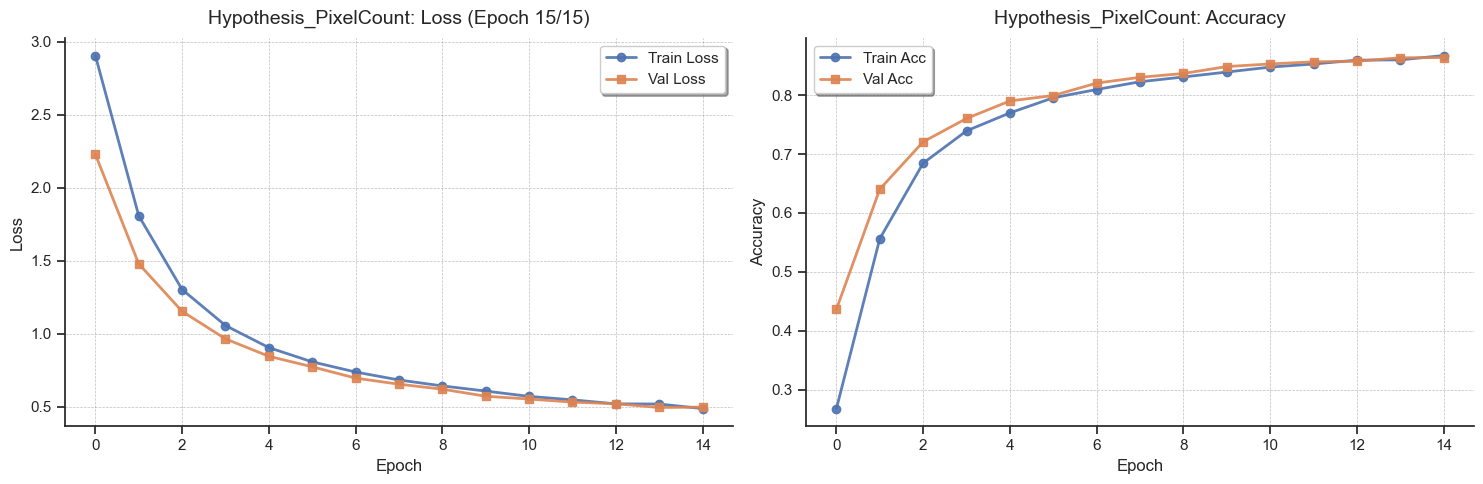

In [8]:
print("\n=== Гипотеза 1: Инженерия признаков (Pixel Count) ===")
# Добавляет долю активных пикселей во Flatten
Hypothesis_PixelCount_model = run_advanced_experiment(
    model_tag="Hypothesis_PixelCount",
    config_kwargs={'use_pixel_count': True},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 5.0, 'bg_loss_n': 2}
)

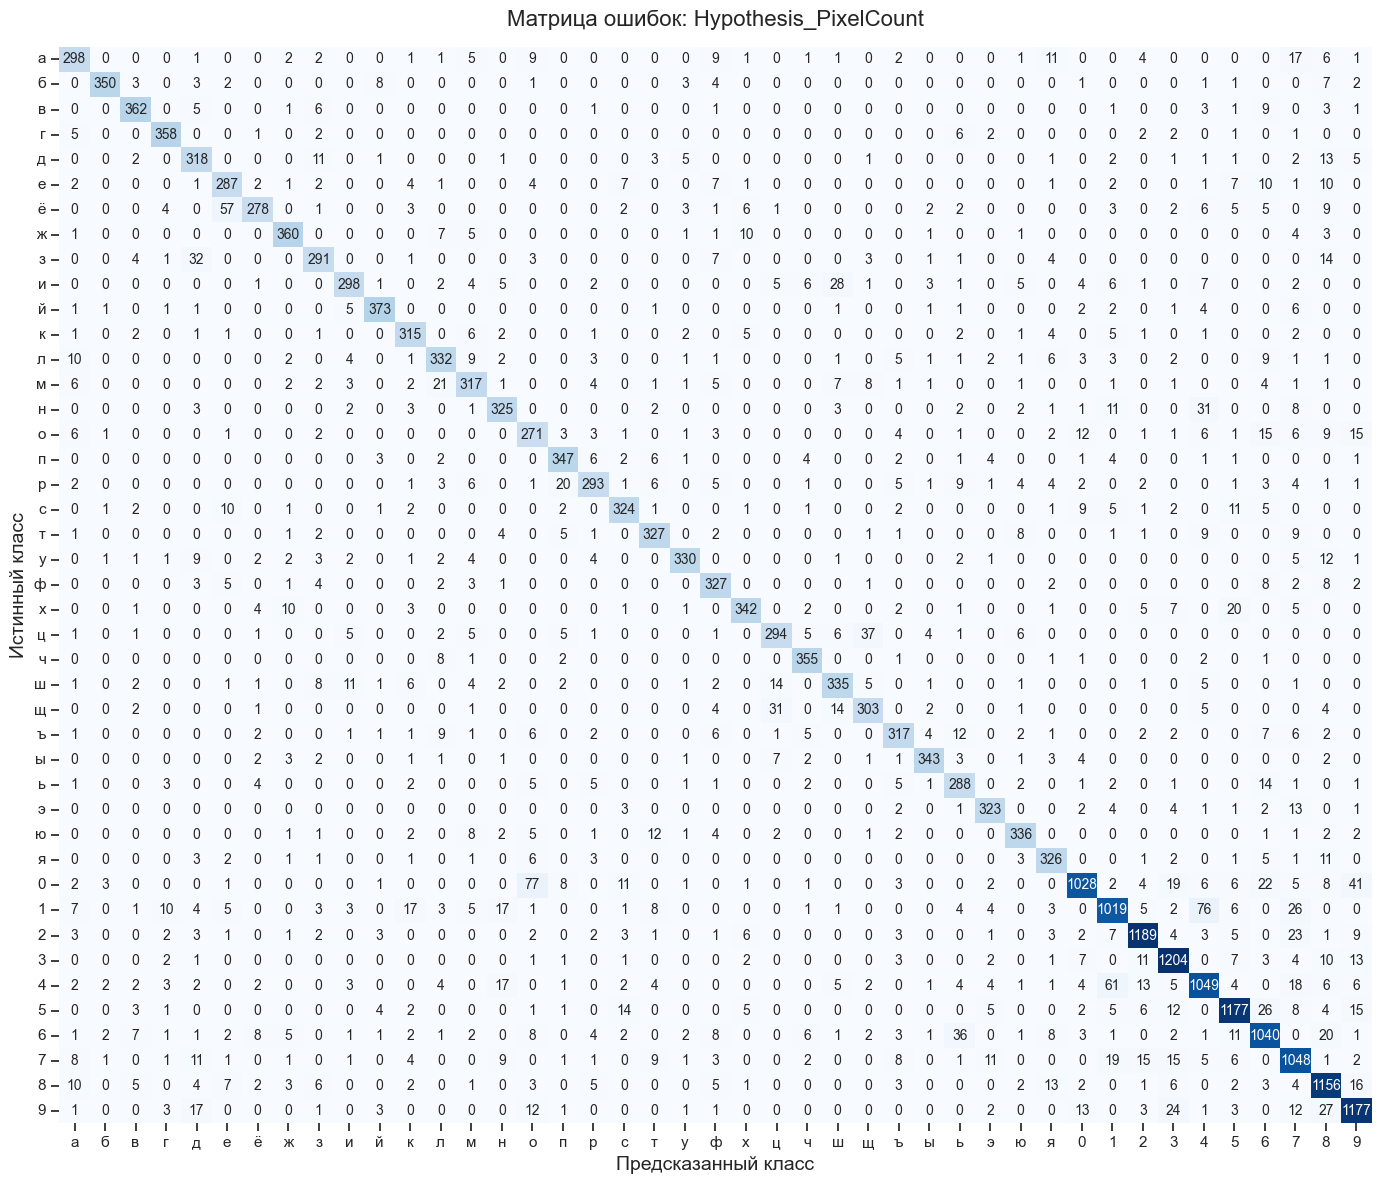

In [9]:
visualizer.plot_confusion_matrix(Hypothesis_PixelCount_model, test_loader, test_dataset, device, model_name="Hypothesis_PixelCount")

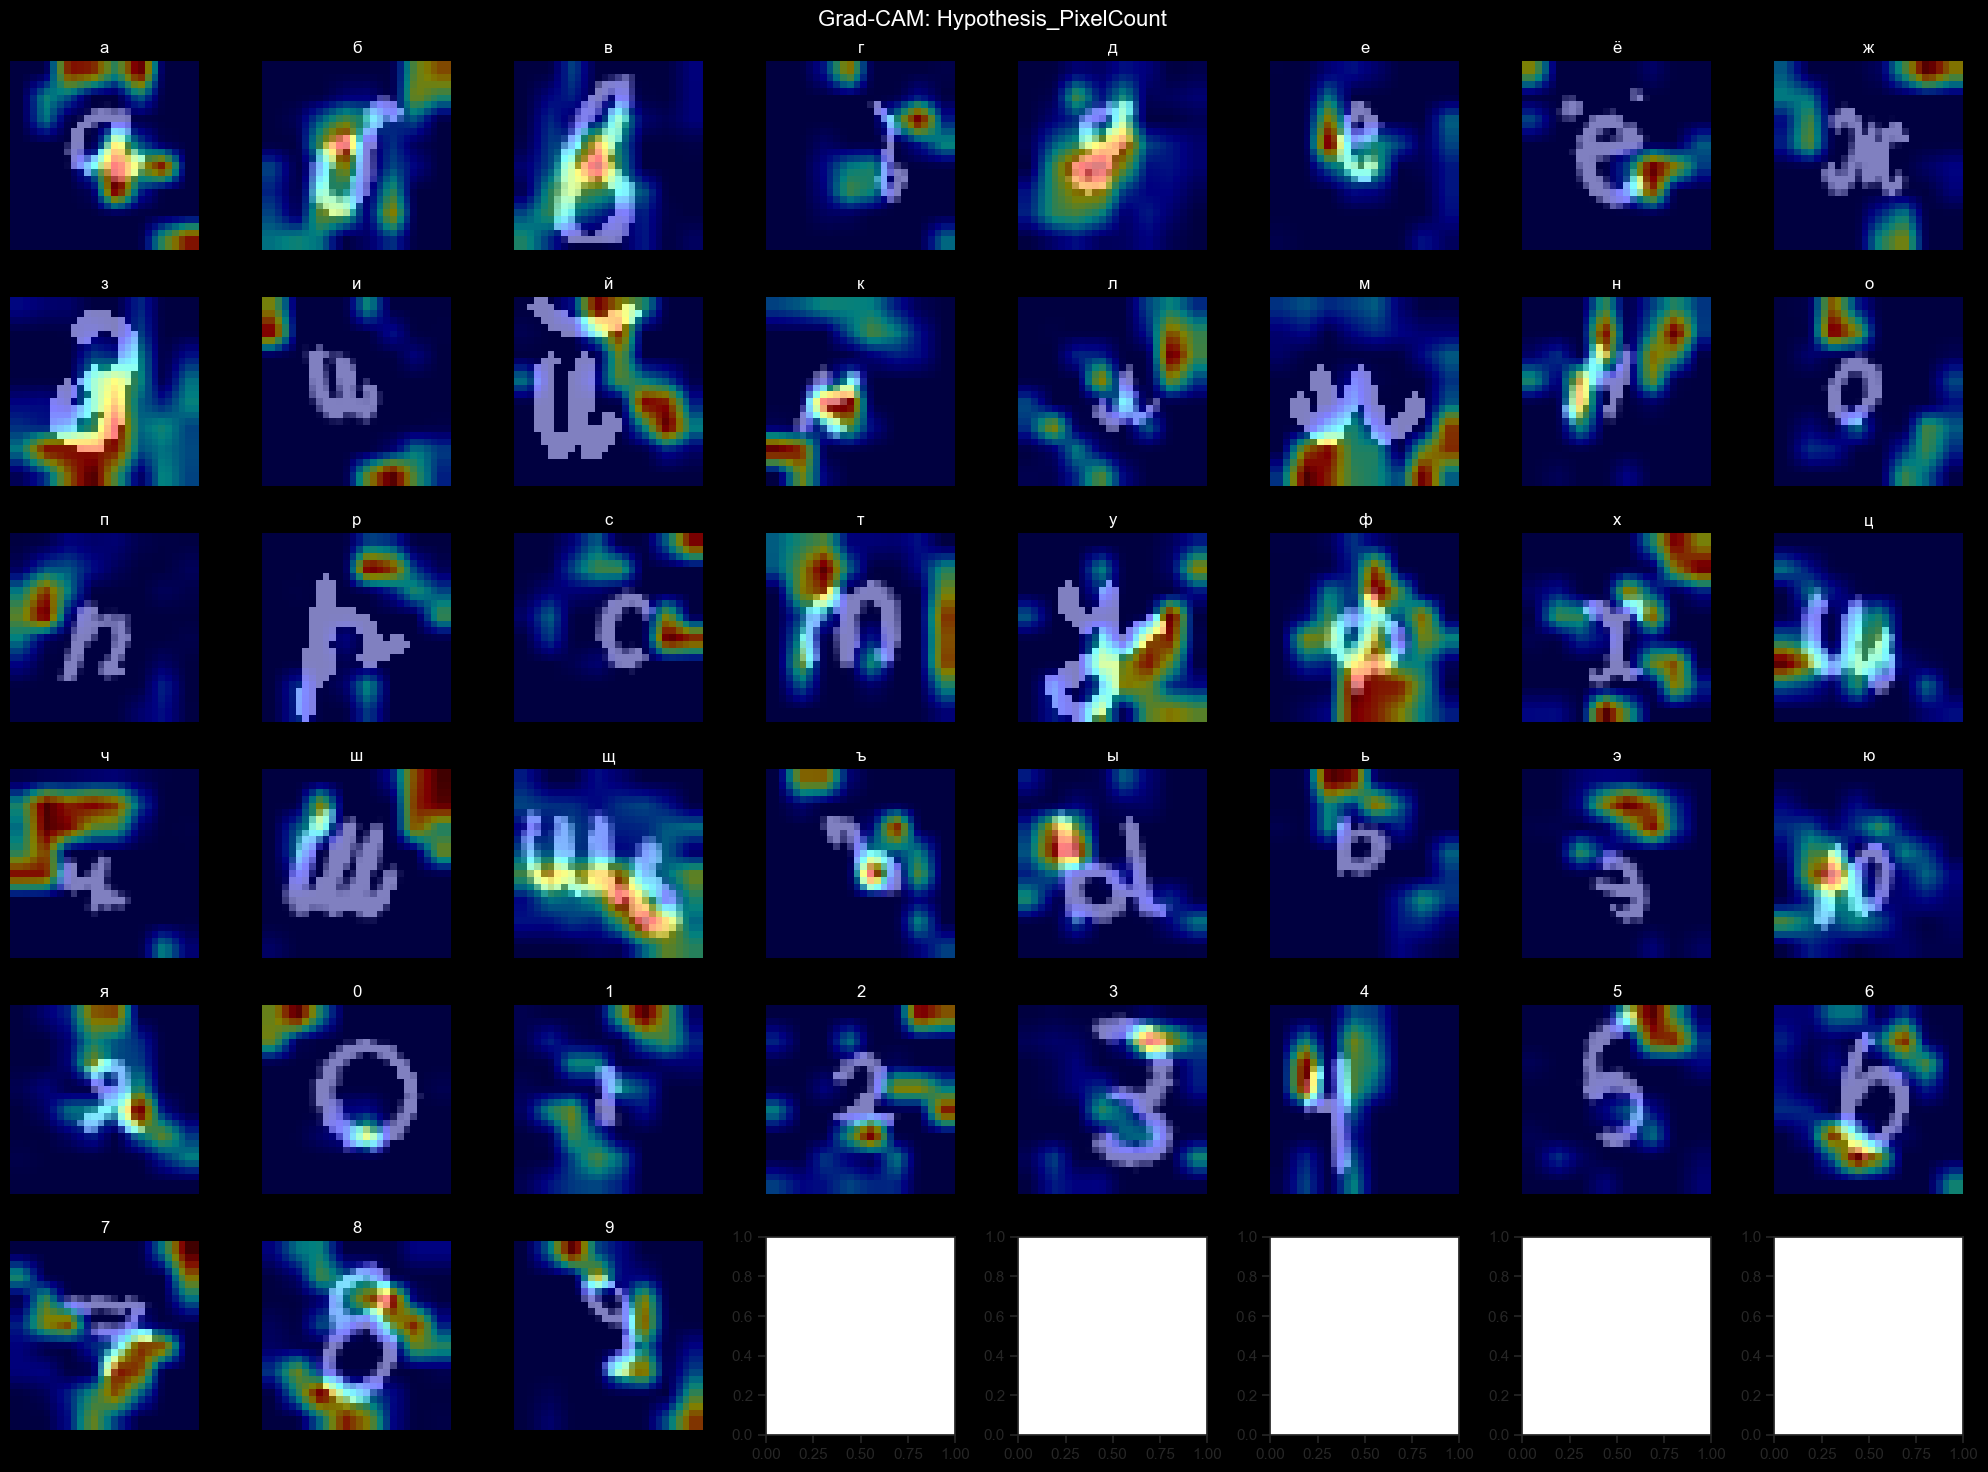

<Figure size 640x480 with 0 Axes>

In [10]:
visualizer.plot_gradcam(Hypothesis_PixelCount_model, test_dataset, device, model_name="Hypothesis_PixelCount")

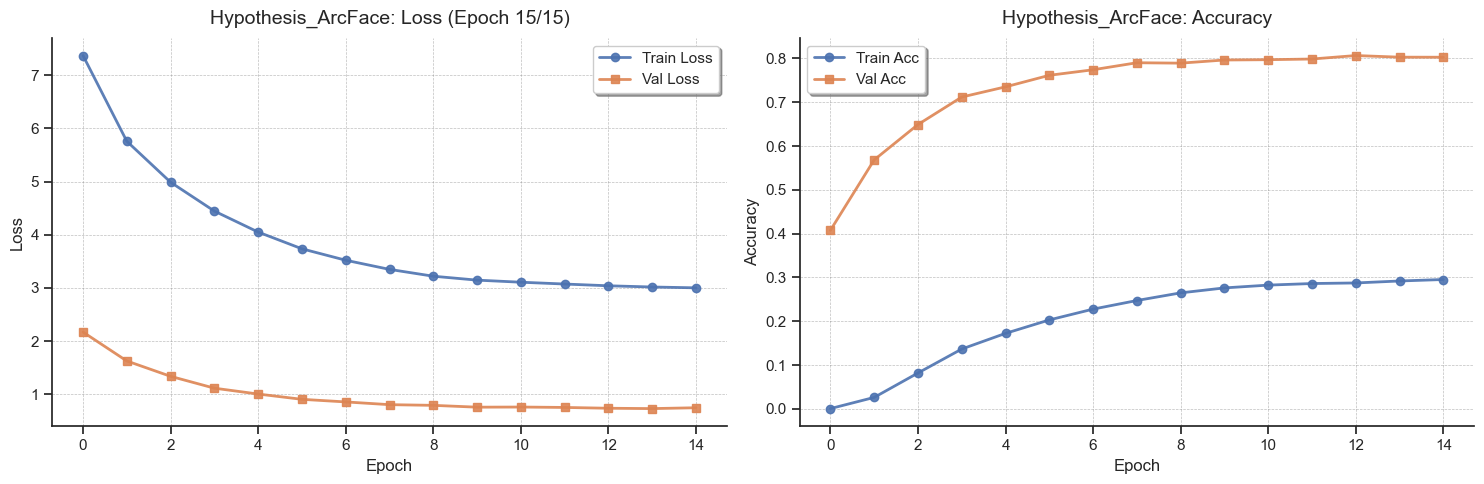

In [11]:
print("\n=== Гипотеза 2: Метрическое обучение (ArcFace) ===")
# Заменяет Linear на ArcFaceLayer для расталкивания классов на гиперсфере
Hypothesis_ArcFace_model = run_advanced_experiment(
    model_tag="Hypothesis_ArcFace",
    config_kwargs={'use_arcface': True},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 5.0, 'bg_loss_n': 2}
)

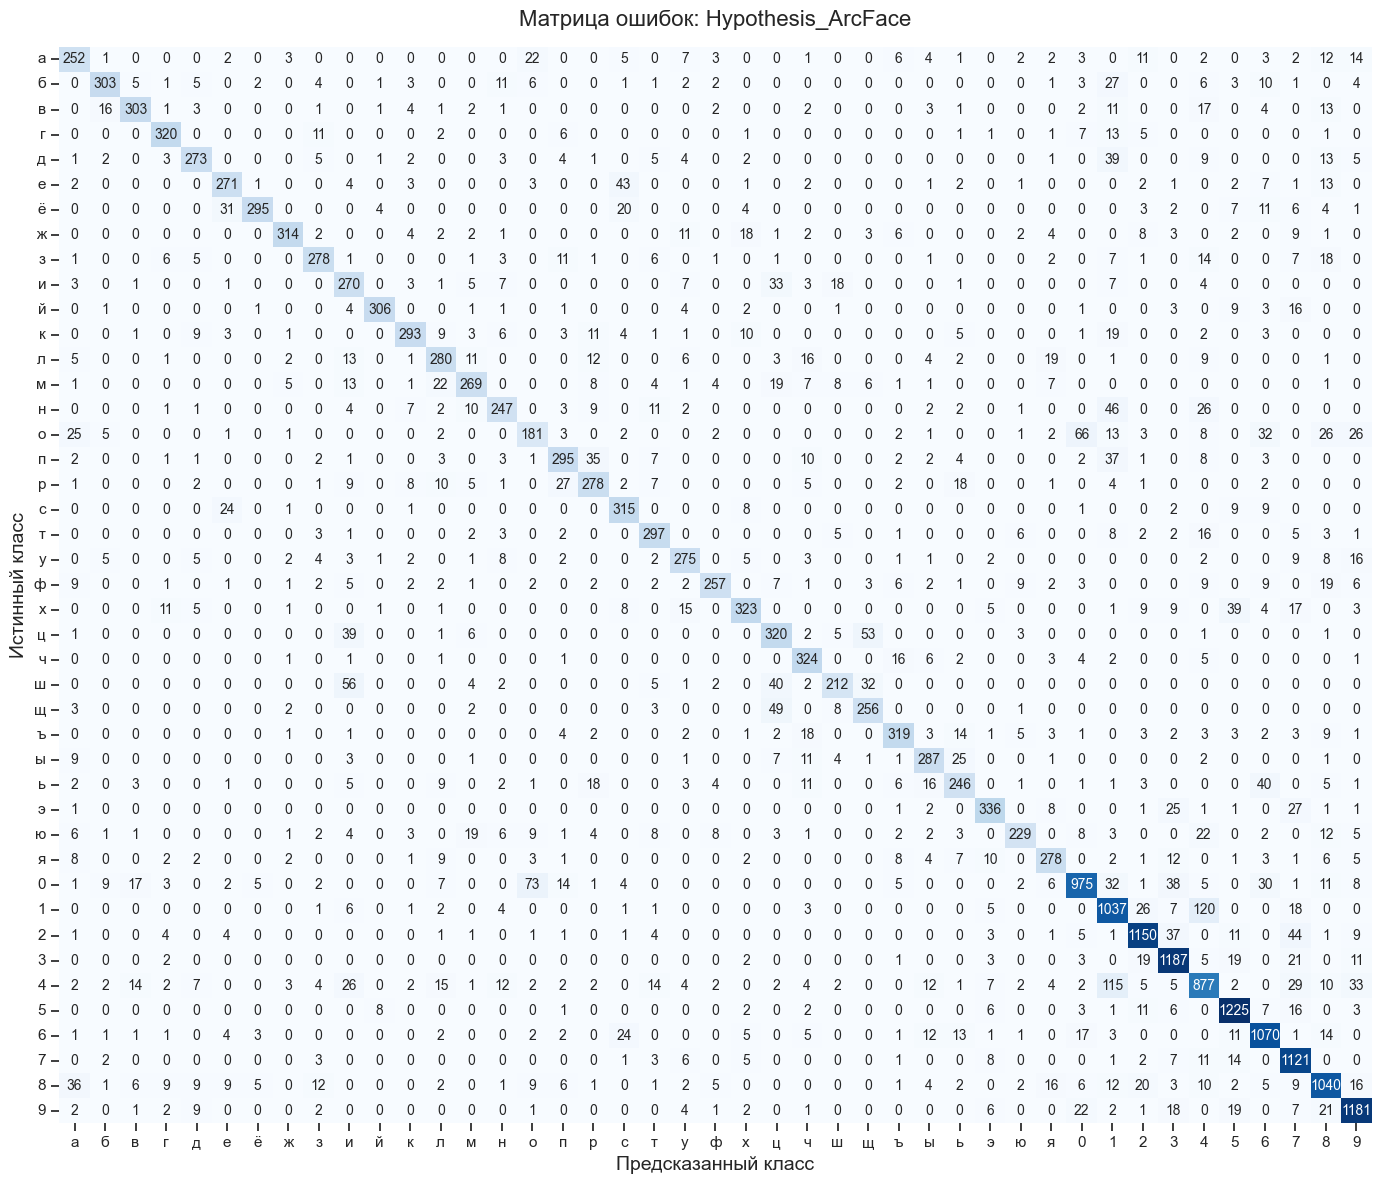

In [12]:
visualizer.plot_confusion_matrix(Hypothesis_ArcFace_model, test_loader, test_dataset, device, model_name="Hypothesis_ArcFace")

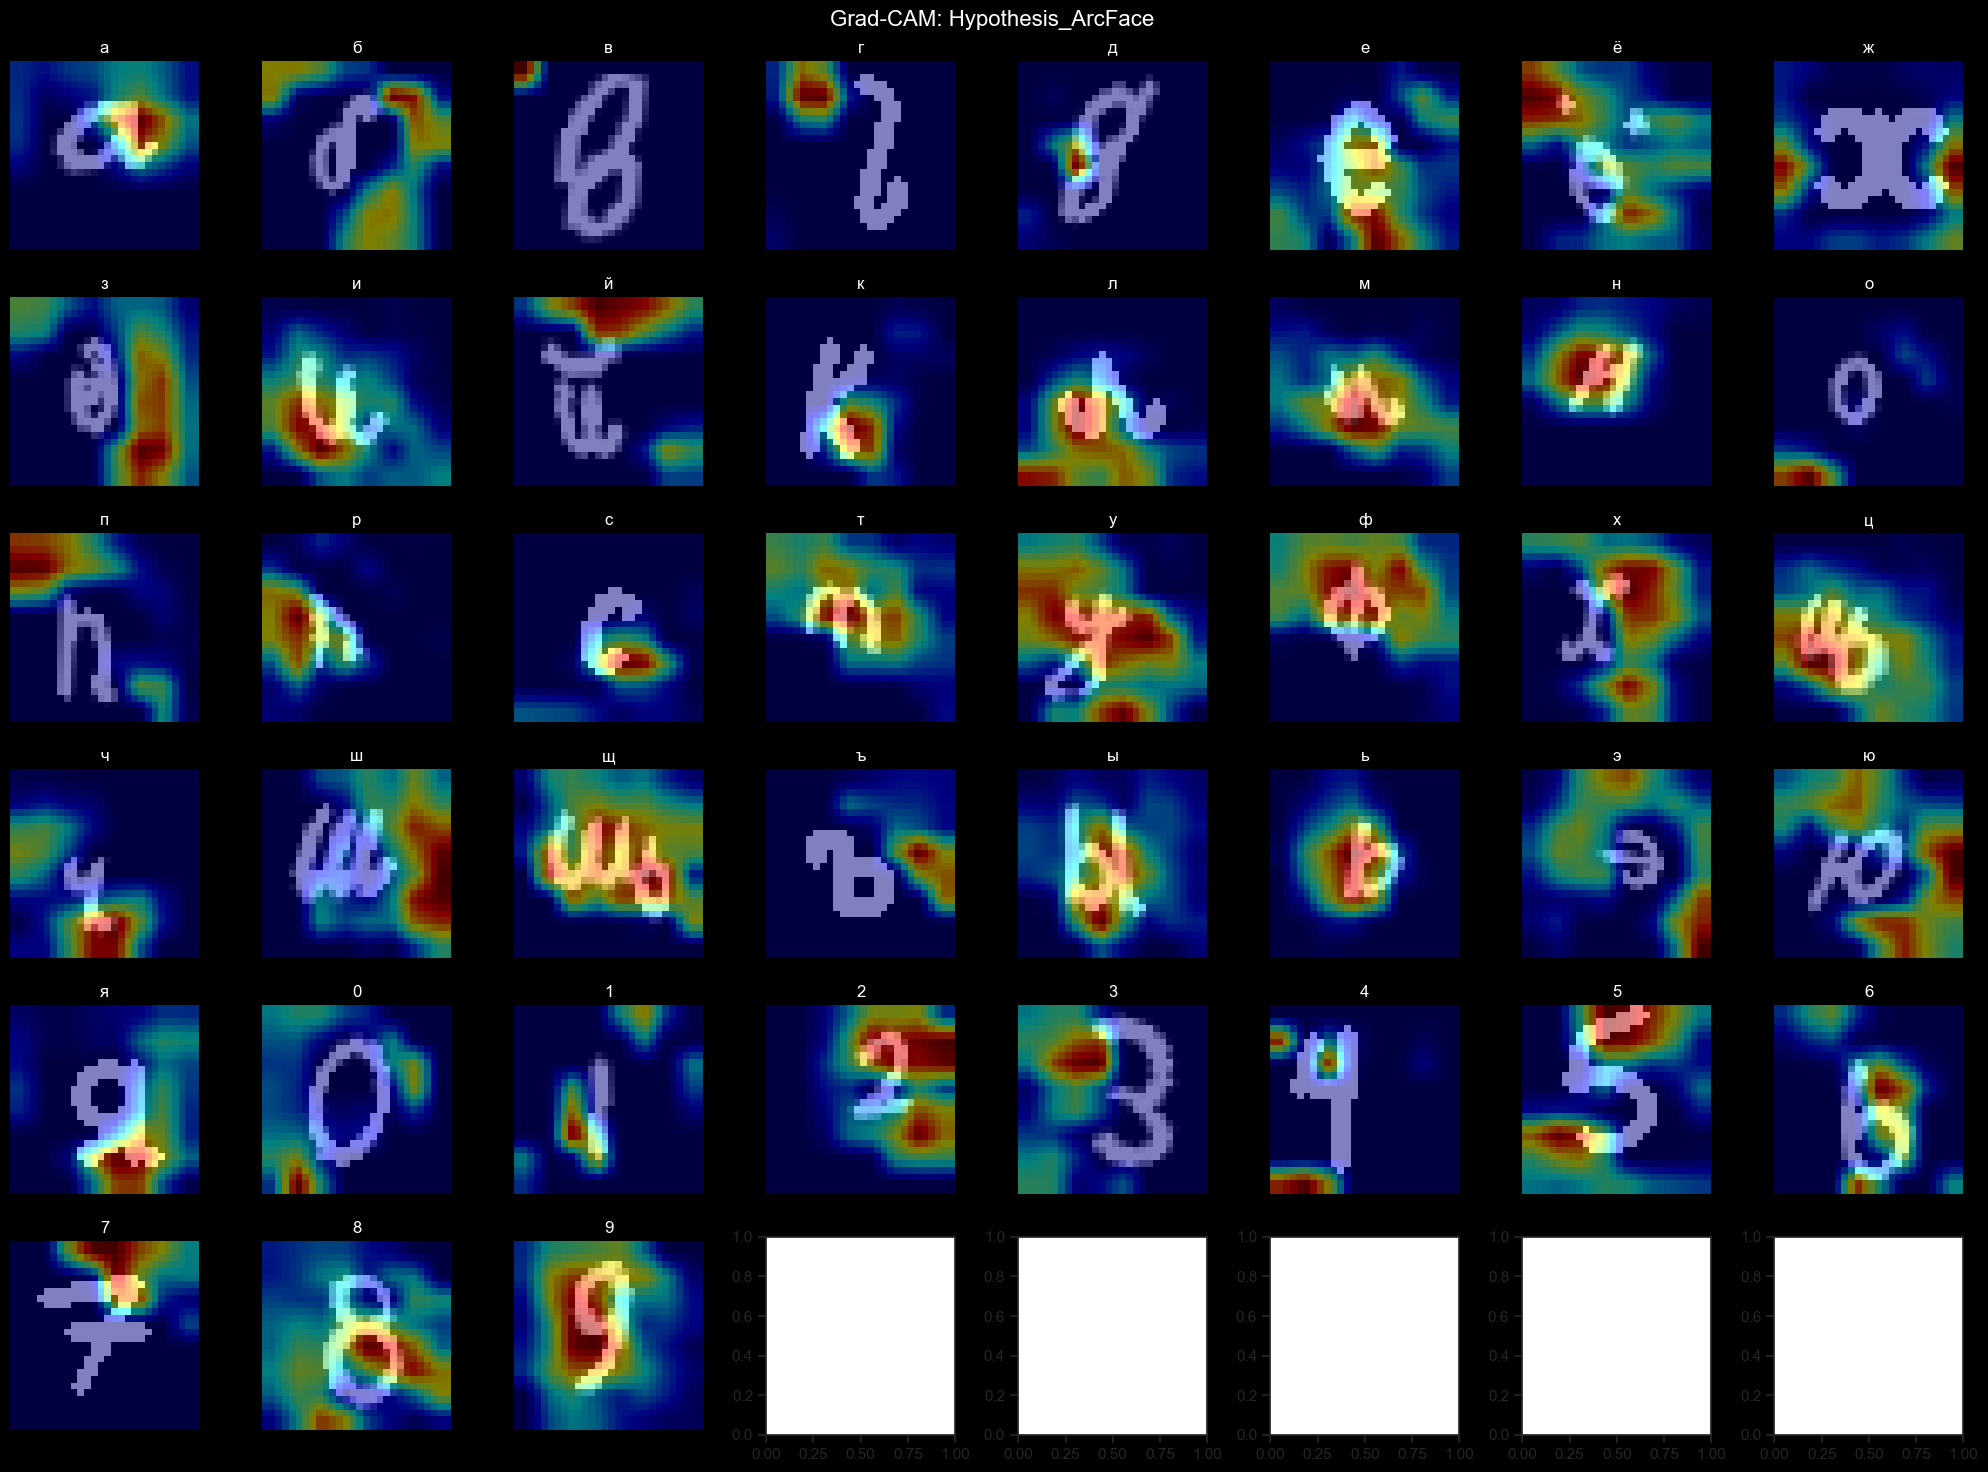

<Figure size 640x480 with 0 Axes>

In [13]:
visualizer.plot_gradcam(Hypothesis_ArcFace_model, test_dataset, device, model_name="Hypothesis_ArcFace")

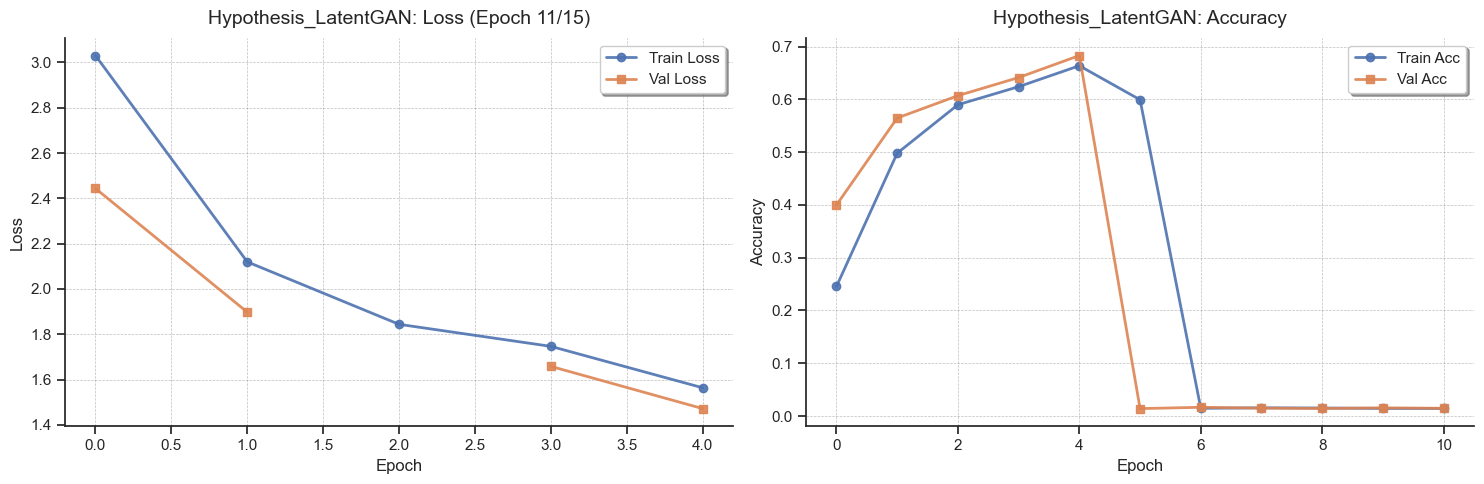

Training:   8%|▊         | 24/293 [00:04<00:53,  5.05it/s, loss=nan]

In [ ]:
print("\n=== Гипотеза 3: Латентная GAN Регуляризация ===")
# Вводит дискриминатор, отличающий латентный вектор от N(0,1)
Hypothesis_LatentGAN_model = run_advanced_experiment(
    model_tag="Hypothesis_LatentGAN",
    config_kwargs={},
    trainer_kwargs={'use_background_loss': True, 'bg_loss_alpha': 5.0, 'bg_loss_n': 2, 'use_gan_loss': True}
)

In [ ]:
visualizer.plot_confusion_matrix(Hypothesis_LatentGAN_model, test_loader, test_dataset, device, model_name="Hypothesis_LatentGAN")

In [ ]:
visualizer.plot_gradcam(Hypothesis_LatentGAN_model, test_dataset, device, model_name="Hypothesis_LatentGAN")